# Task 2: SVM (15 points)

## 2(a) Shuffle, Split, and Baseline SVM
Shuffle the data and split it into training, validation, and testing sets (60% / 20% / 20%). Then, train an SVM classifier with `C=1.0`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# 1. Load data
df = pd.read_csv('mobile_price.csv')
X = df.drop('price_range', axis=1)
y = df['price_range']

# 2. Shuffle and split (60% Train, 20% Val, 20% Test)
# First split: 60% Train, 40% Temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, shuffle=True)
# Second split: Split Temp into half (20% Val, 20% Test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True)

print(f"Train shape: {X_train.shape}")
print(f"Val shape:   {X_val.shape}")
print(f"Test shape:  {X_test.shape}")

Train shape: (1200, 20)
Val shape:   (400, 20)
Test shape:  (400, 20)


In [2]:
# 3. Train Baseline SVM (C=1.0)
svm_baseline = SVC(C=1.0, random_state=42)
svm_baseline.fit(X_train, y_train)

def evaluate_svm(model, X, y, set_name):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average='weighted')
    print(f"{set_name} - Accuracy: {acc:.4f}, F1-score: {f1:.4f}")
    return acc, f1

print("Baseline SVM (C=1.0) Results:")
evaluate_svm(svm_baseline, X_train, y_train, "Training  ")
evaluate_svm(svm_baseline, X_val, y_val, "Validation")
evaluate_svm(svm_baseline, X_test, y_test, "Testing   ")

Baseline SVM (C=1.0) Results:
Training   - Accuracy: 0.9450, F1-score: 0.9445
Validation - Accuracy: 0.9450, F1-score: 0.9448
Testing    - Accuracy: 0.9575, F1-score: 0.9573


(0.9575, 0.9572715467431775)

## 2(b) Parameter Tuning for C
Explore different values of `C` and visualize the performance changes.

Training SVM with C=0.001...
Training SVM with C=0.01...
Training SVM with C=0.1...
Training SVM with C=1...
Training SVM with C=10...
Training SVM with C=100...
Training SVM with C=1000...
Training SVM with C=10000...


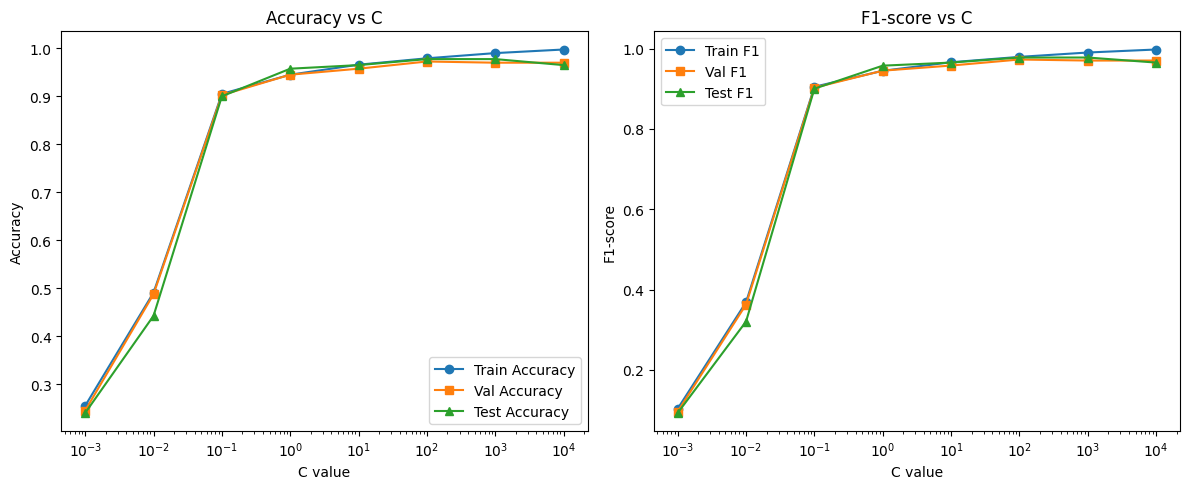

In [3]:
c_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
train_accs, val_accs, test_accs = [], [], []
train_f1s, val_f1s, test_f1s = [], [], []

for c in c_values:
    print(f"Training SVM with C={c}...")
    model = SVC(C=c, random_state=42)
    model.fit(X_train, y_train)
    
    train_accs.append(accuracy_score(y_train, model.predict(X_train)))
    val_accs.append(accuracy_score(y_val, model.predict(X_val)))
    test_accs.append(accuracy_score(y_test, model.predict(X_test)))
    
    train_f1s.append(f1_score(y_train, model.predict(X_train), average='weighted'))
    val_f1s.append(f1_score(y_val, model.predict(X_val), average='weighted'))
    test_f1s.append(f1_score(y_test, model.predict(X_test), average='weighted'))

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(c_values, train_accs, label='Train Accuracy', marker='o')
plt.plot(c_values, val_accs, label='Val Accuracy', marker='s')
plt.plot(c_values, test_accs, label='Test Accuracy', marker='^')
plt.xscale('log')
plt.xlabel('C value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs C')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(c_values, train_f1s, label='Train F1', marker='o')
plt.plot(c_values, val_f1s, label='Val F1', marker='s')
plt.plot(c_values, test_f1s, label='Test F1', marker='^')
plt.xscale('log')
plt.xlabel('C value')
plt.ylabel('F1-score')
plt.title('F1-score vs C')
plt.legend()

plt.tight_layout()
plt.show()

## 2(c) Observations and Best Generalization Performance
Based on the results, describe your observations and determine which C value is best.